<a href="https://colab.research.google.com/github/SManojna/ai-engineering/blob/main/reviews%20/ML_Algo%20/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression
Learns the best weights and bias to fit a straight line through data using Gradient Descent.

## Why we need each component

- **Learning Rate (lr):** Controls step size. Too high = overshoots. Too low = slow.
- **Weights (w):** One per feature. How much each feature contributes to prediction.
- **Bias (b):** Shifts line up or down. Without it line is forced through origin.
- **n_samples:** Total data points. Used to average gradients.
- **n_features:** Total input columns. Determines how many weights to initialize.
- **n_iters:** Number of training loops. More = closer to optimal weights.

## Formulas

- **Prediction:** y_pred = Xw + b
- **Loss (MSE):** (1/n) * sum((y_pred - y_true)²)
- **Gradient w:** dw = (2/n) * Xᵀ @ (y_pred - y_true)
- **Gradient b:** db = (2/n) * sum(y_pred - y_true)
- **Update:** w = w - lr * dw | b = b - lr * db

## How Gradient Descent links to Linear Regression

Linear regression finds the best w and b such that **y = Xw + b** fits the data.

Gradient Descent finds them by:
1. Start with weights at zero
2. Predict y using current weights
3. Measure error — MSE
4. Compute gradients — which direction reduces error?
5. Subtract lr * gradient from weights
6. Repeat until loss converges

> Without Gradient Descent: y = Xw + b is just a formula with no way to learn.
> With Gradient Descent: it becomes a learning algorithm.

## Overall Picture

`Initialize → Predict → Measure Error → Compute Gradients → Update Weights → Repeat`

Every neural network ever built uses this exact same mechanism.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
class LinearRegression:

    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros( n_features)
        self.bias = 0
        for _ in range(self.n_iters):
            #y_pred = Xw + b
            y_predicted = self.predict(X)
            # dw = (2/n) * Xᵀ @ (y_pred - y_true)
            dw = (2 / n_samples) * np.dot(X.T, (y_predicted - y))
            # db = (2/n) * sum(y_pred - y_true)
            db = (2 / n_samples) * np.sum(y_predicted - y)
            # w = w - lr * dw
            self.weights -= self.lr*dw
            # b = b - lr * db
            self.bias -= self.lr*db
            if _ % 100 == 0:
              loss = self.mse(y, y_predicted)
              print(f"Epoch {_} Loss: {loss:.4f}")

    def predict(self, X):
        y_predicted = np.dot(X, self.weights) + self.bias
        return y_predicted

    def mse(self, y_true, y_pred):
      return np.mean((y_true - y_pred)**2)

In [6]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X.flatten() + np.random.randn(100)

model = LinearRegression(lr=0.01, n_iters=1000)
model.fit(X, y)
predictions = model.predict(X)

Epoch 0 Loss: 52.7353
Epoch 100 Loss: 1.2515
Epoch 200 Loss: 1.1984
Epoch 300 Loss: 1.1726
Epoch 400 Loss: 1.1576
Epoch 500 Loss: 1.1490
Epoch 600 Loss: 1.1439
Epoch 700 Loss: 1.1410
Epoch 800 Loss: 1.1393
Epoch 900 Loss: 1.1383


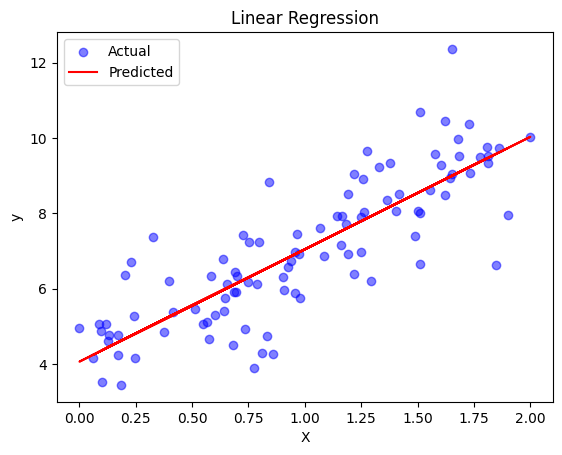

In [7]:
plt.scatter(X, y, color='blue', label='Actual', alpha=0.5)
plt.plot(X, predictions, color='red', label='Predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.show()

In [8]:
X = 2 * np.random.rand(100, 3)  # 3 columns
y = 4 + 3*X[:,0] + 2*X[:,1] + 5*X[:,2] + np.random.randn(100)


model = LinearRegression(lr=0.05, n_iters=3000)
model.fit(X, y)
predictions = model.predict(X)


Epoch 0 Loss: 194.2792
Epoch 100 Loss: 0.9187
Epoch 200 Loss: 0.9017
Epoch 300 Loss: 0.8991
Epoch 400 Loss: 0.8984
Epoch 500 Loss: 0.8983
Epoch 600 Loss: 0.8982
Epoch 700 Loss: 0.8982
Epoch 800 Loss: 0.8982
Epoch 900 Loss: 0.8982
Epoch 1000 Loss: 0.8982
Epoch 1100 Loss: 0.8982
Epoch 1200 Loss: 0.8982
Epoch 1300 Loss: 0.8982
Epoch 1400 Loss: 0.8982
Epoch 1500 Loss: 0.8982
Epoch 1600 Loss: 0.8982
Epoch 1700 Loss: 0.8982
Epoch 1800 Loss: 0.8982
Epoch 1900 Loss: 0.8982
Epoch 2000 Loss: 0.8982
Epoch 2100 Loss: 0.8982
Epoch 2200 Loss: 0.8982
Epoch 2300 Loss: 0.8982
Epoch 2400 Loss: 0.8982
Epoch 2500 Loss: 0.8982
Epoch 2600 Loss: 0.8982
Epoch 2700 Loss: 0.8982
Epoch 2800 Loss: 0.8982
Epoch 2900 Loss: 0.8982


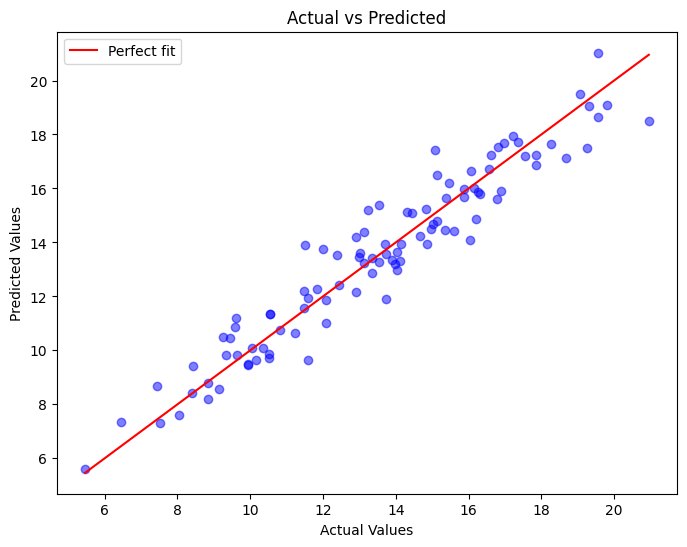

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(y, predictions, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', label='Perfect fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

## Multilinear Regression

Extension of simple linear regression to multiple input features.
Same algorithm. Same gradient descent. Different data shape.



### What changes with multiple features

- **Simple:** y = w₁x₁ + b (1 weight, 1 feature)
- **Multiple:** y = w₁x₁ + w₂x₂ + w₃x₃ + b (1 weight per feature)

In matrix form both are the same:
y = Xw + b

The code does not change. Only the input data shape changes.

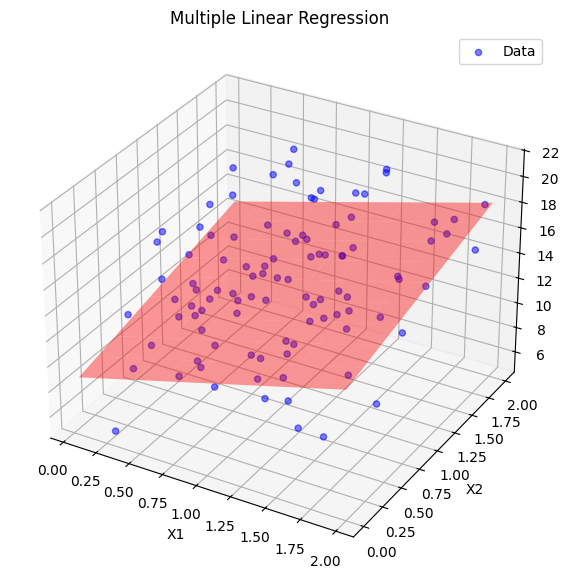

In [10]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot actual data points using X1 and X2 only
ax.scatter(X[:, 0], X[:, 1], y, color='blue', alpha=0.5, label='Data')

# Create a grid for X1 and X2
x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 10)
x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 10)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Fix X3 at its mean value
x3_mean = np.full(x1_grid.shape, X[:, 2].mean())

# Stack into feature matrix and predict
grid_points = np.c_[x1_grid.ravel(), x2_grid.ravel(), x3_mean.ravel()]
y_grid = model.predict(grid_points).reshape(x1_grid.shape)

# Plot the fitted plane
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.4, color='red')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title('Multiple Linear Regression')
plt.legend()
plt.show()

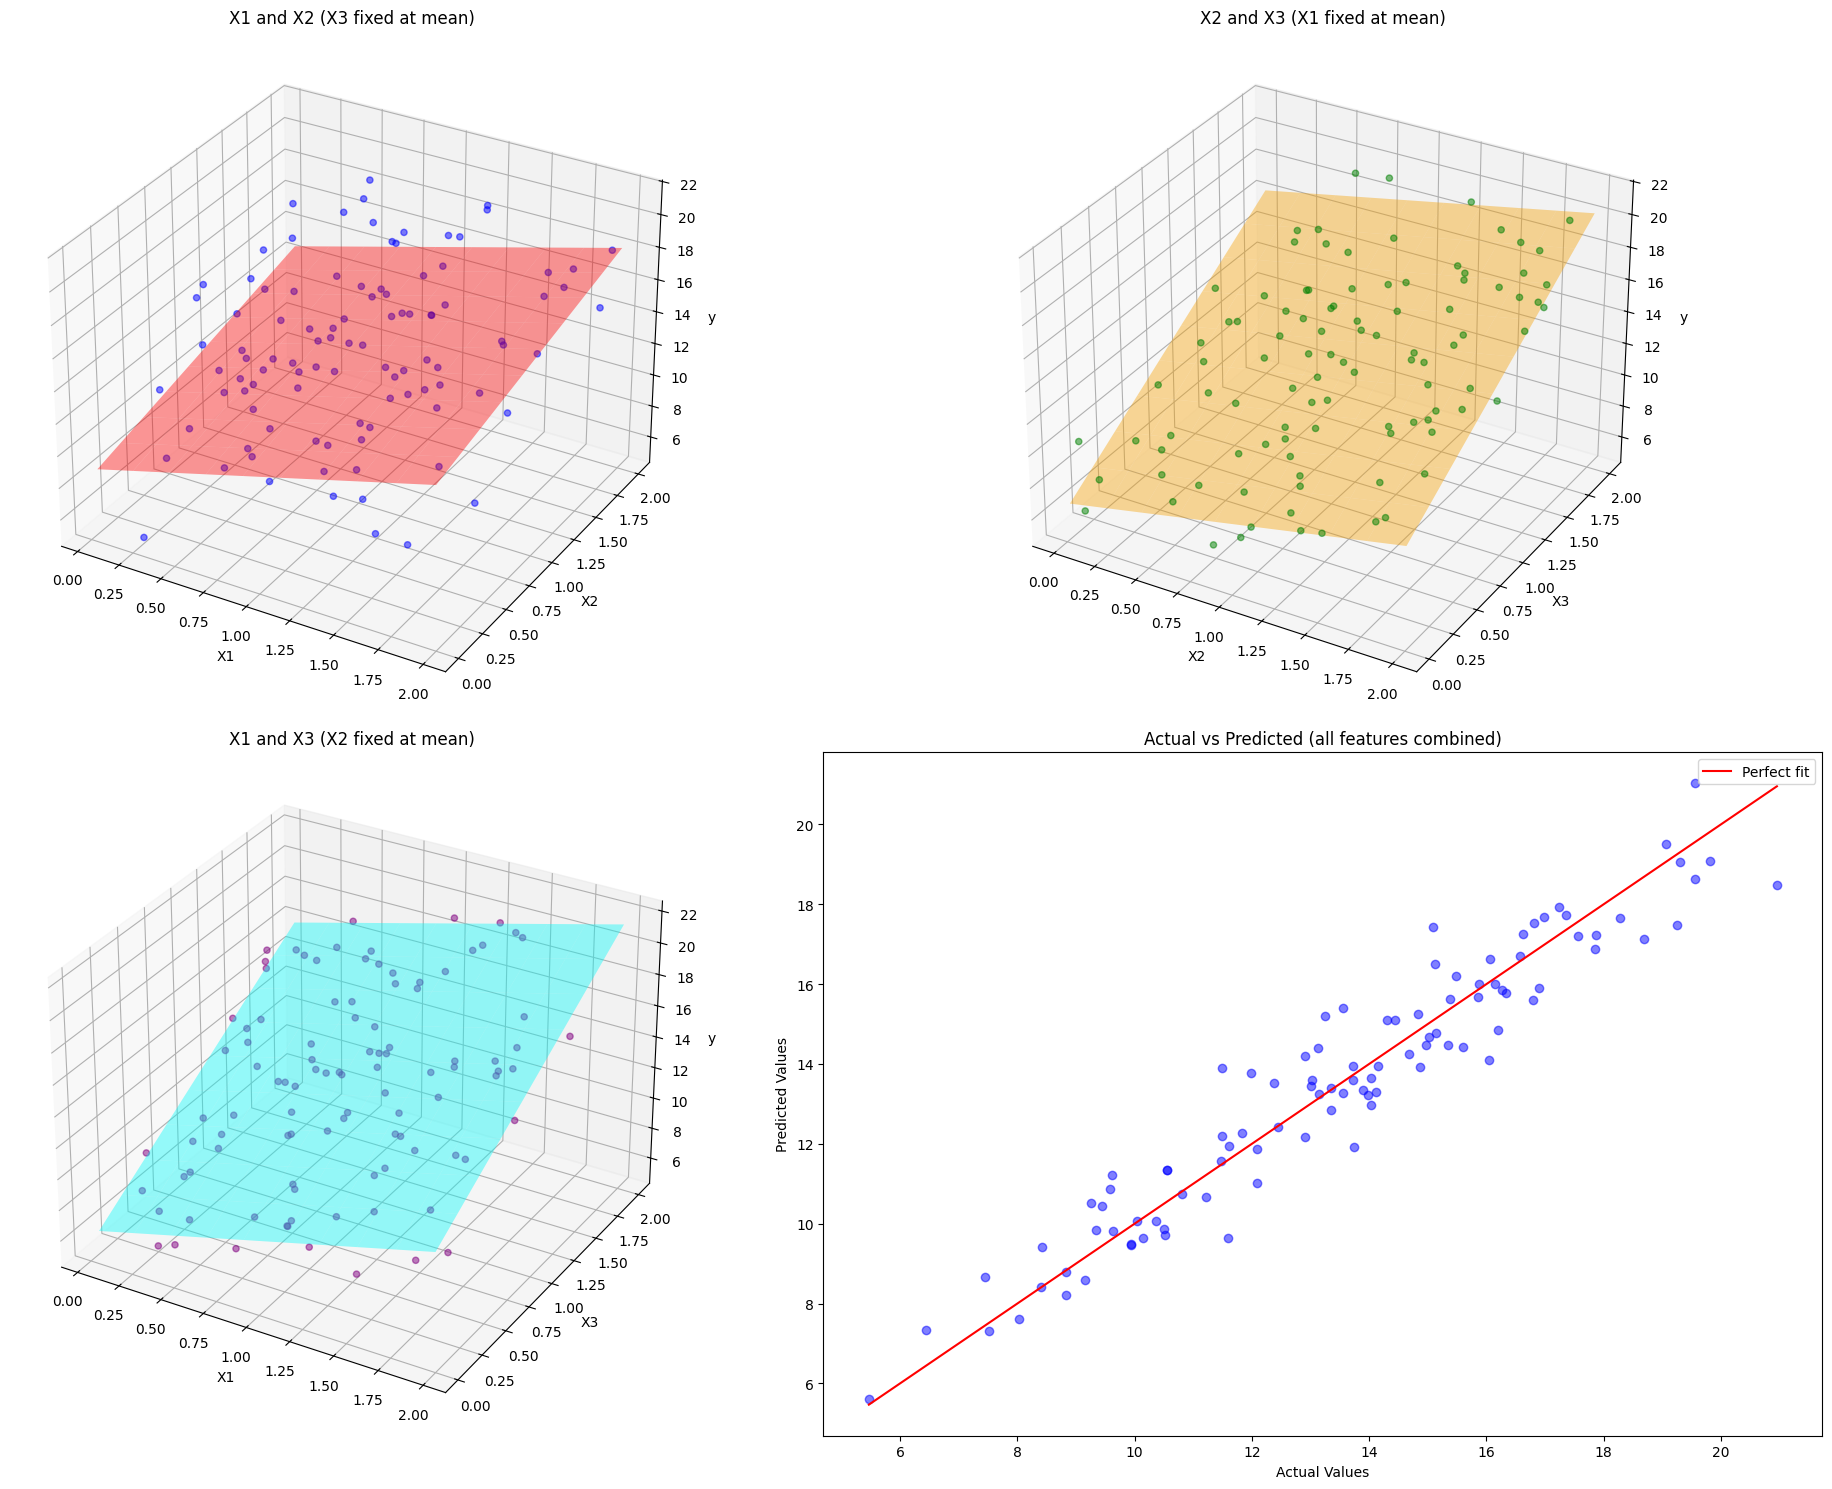

In [11]:
fig = plt.figure(figsize=(20, 15))

# Plot 1 — X1 and X2 (fixing X3 at mean)
ax1 = fig.add_subplot(221, projection='3d')
x1_range = np.linspace(X[:,0].min(), X[:,0].max(), 10)
x2_range = np.linspace(X[:,1].min(), X[:,1].max(), 10)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
x3_mean = np.full(x1_grid.shape, X[:,2].mean())
grid = np.c_[x1_grid.ravel(), x2_grid.ravel(), x3_mean.ravel()]
y_grid = model.predict(grid).reshape(x1_grid.shape)
ax1.scatter(X[:,0], X[:,1], y, color='blue', alpha=0.5)
ax1.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.4, color='red')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('y')
ax1.set_title('X1 and X2 (X3 fixed at mean)')

# Plot 2 — X2 and X3 (fixing X1 at mean)
ax2 = fig.add_subplot(222, projection='3d')
x2_range = np.linspace(X[:,1].min(), X[:,1].max(), 10)
x3_range = np.linspace(X[:,2].min(), X[:,2].max(), 10)
x2_grid, x3_grid = np.meshgrid(x2_range, x3_range)
x1_mean = np.full(x2_grid.shape, X[:,0].mean())
grid = np.c_[x1_mean.ravel(), x2_grid.ravel(), x3_grid.ravel()]
y_grid = model.predict(grid).reshape(x2_grid.shape)
ax2.scatter(X[:,1], X[:,2], y, color='green', alpha=0.5)
ax2.plot_surface(x2_grid, x3_grid, y_grid, alpha=0.4, color='orange')
ax2.set_xlabel('X2')
ax2.set_ylabel('X3')
ax2.set_zlabel('y')
ax2.set_title('X2 and X3 (X1 fixed at mean)')

# Plot 3 — X1 and X3 (fixing X2 at mean)
ax3 = fig.add_subplot(223, projection='3d')
x1_range = np.linspace(X[:,0].min(), X[:,0].max(), 10)
x3_range = np.linspace(X[:,2].min(), X[:,2].max(), 10)
x1_grid, x3_grid = np.meshgrid(x1_range, x3_range)
x2_mean = np.full(x1_grid.shape, X[:,1].mean())
grid = np.c_[x1_grid.ravel(), x2_mean.ravel(), x3_grid.ravel()]
y_grid = model.predict(grid).reshape(x1_grid.shape)
ax3.scatter(X[:,0], X[:,2], y, color='purple', alpha=0.5)
ax3.plot_surface(x1_grid, x3_grid, y_grid, alpha=0.4, color='cyan')
ax3.set_xlabel('X1')
ax3.set_ylabel('X3')
ax3.set_zlabel('y')
ax3.set_title('X1 and X3 (X2 fixed at mean)')

# Plot 4 — Actual vs Predicted (combines all three features)
ax4 = fig.add_subplot(224)
ax4.scatter(y, predictions, color='blue', alpha=0.5)
ax4.plot([y.min(), y.max()], [y.min(), y.max()], color='red', label='Perfect fit')
ax4.set_xlabel('Actual Values')
ax4.set_ylabel('Predicted Values')
ax4.set_title('Actual vs Predicted (all features combined)')
ax4.legend()

plt.tight_layout()
plt.show()